# Working with complicated dataset

Your name: Hrishikesh Giri

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [19]:
import pandas as pd
import io
import urllib.request
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv'

with urllib.request.urlopen(url) as response:
    raw_lines = [line.decode('utf-8').strip() for line in response.readlines()]

for line in raw_lines:
    if '# Fields:' in line:
        fields_str = line.strip('"').split('# Fields:')[-1].strip().rstrip('"')
        header = [c.strip().strip('"') for c in fields_str.split(',') if c.strip()]
        break

data_lines = [l for l in raw_lines if l.strip() and not l.startswith('#') and not l.startswith('"#')]

df = pd.read_csv(io.StringIO('\n'.join(data_lines)), header=None, names=header + ['_extra'])

df = df.drop(columns=['_extra', 'query acc.ver'])
df = df.set_index('subject acc.ver')

df['bonds'] = df['bonds'].astype(str).str.strip().str.replace(',', '').pipe(pd.to_numeric, errors='coerce')

df['publications'] = pd.to_numeric(df['publications'], errors='coerce')

display(df.head())

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0


### Question 2
What is the average number of publications?

In [20]:
avg_publications = df['publications'].mean()
print(f"The average number of publications is: {avg_publications}")

The average number of publications is: 26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [21]:
high_bond_subjects = df[df['bonds'] > 15000].index.tolist()
print("Subjects with over 15,000 bonds:")
print(high_bond_subjects)

Subjects with over 15,000 bonds:
['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1', '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1', 'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1', 'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1', 'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1', 'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1', 'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1', 'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1', 'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1']


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

<Axes: title={'center': 'Correlation between % Identity and % Positives'}, xlabel='% identity', ylabel='% positives'>

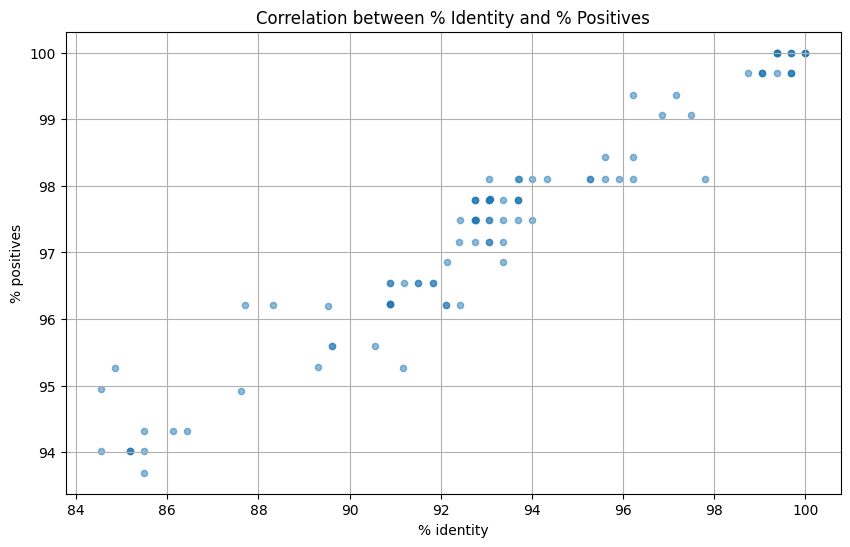

In [22]:
df.plot.scatter(x='% identity', y='% positives', alpha=0.5,
                title='Correlation between % Identity and % Positives',
                figsize=(10, 6), grid=True)

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [23]:

source_url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv'
protein_source_df = pd.read_csv(source_url)

df = df.reset_index()
df['subject acc.ver'] = df['subject acc.ver'].astype(str)
protein_source_df['Protein'] = protein_source_df['Protein'].astype(str)

df = df.merge(
    protein_source_df[['Protein', 'Source']],
    left_on='subject acc.ver',
    right_on='Protein',
    how='left'
).drop(columns=['Protein']).rename(columns={'Source': 'Protein source'}).set_index('subject acc.ver')

display(df.head())

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
